In [2]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

print("TensorFlow:", tf.__version__)

TensorFlow: 2.15.0


In [3]:
dataset3_images = Path("../dataset/woundDataset3")
dataset3_masks = Path("../dataset/woundDataset3_pseudo_masks")

image_paths = sorted(
    list(dataset3_images.glob("*.jpg")) +
    list(dataset3_images.glob("*.jpeg")) +
    list(dataset3_images.glob("*.png"))
)

print("Total images:", len(image_paths))
print("Pseudo-mask directory:", dataset3_masks)

Total images: 1000
Pseudo-mask directory: ../dataset/woundDataset3_pseudo_masks


In [4]:
valid_pairs = []

for image_path in image_paths:

    mask_path = dataset3_masks / f"{image_path.stem}.png"

    if mask_path.exists():
        valid_pairs.append((image_path, mask_path))

print("Valid image-mask pairs:", len(valid_pairs))

Valid image-mask pairs: 1000


In [5]:
train_pairs, val_pairs = train_test_split(
    valid_pairs,
    test_size=0.2,
    random_state=42
)

print("Training pairs:", len(train_pairs))
print("Validation pairs:", len(val_pairs))

Training pairs: 800
Validation pairs: 200


In [6]:
IMG_SIZE = 256
BATCH_SIZE = 2

def load_pair(image_path, mask_path):
    
    # Read image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )
    image = tf.image.resize(
        image,
        [IMG_SIZE, IMG_SIZE]
    )
    image = tf.cast(image, tf.float32) / 255.0

    # Read pseudo-mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(
        mask,
        channels=1
    )
    mask = tf.image.resize(
        mask,
        [IMG_SIZE, IMG_SIZE],
        method="nearest"
    )
    mask = tf.cast(mask, tf.float32) / 255.0

    return image, mask

In [7]:
train_image_paths = [str(pair[0]) for pair in train_pairs]
train_mask_paths = [str(pair[1]) for pair in train_pairs]

val_image_paths = [str(pair[0]) for pair in val_pairs]
val_mask_paths = [str(pair[1]) for pair in val_pairs]

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_image_paths, train_mask_paths)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_image_paths, val_mask_paths)
)

train_ds = train_ds.map(
    load_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.map(
    load_pair,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(800).batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(
    tf.data.AUTOTUNE
)

print("Dataset pipeline created!")

Dataset pipeline created!


2026-09-05 23:49:34.304670: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-05 23:49:34.309768: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-09-05 23:49:34.313472: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [8]:
sample_images, sample_masks = next(iter(train_ds))

print("Images:", sample_images.shape)
print("Masks:", sample_masks.shape)

print(
    "Image range:",
    sample_images.numpy().min(),
    sample_images.numpy().max()
)

print(
    "Mask range:",
    sample_masks.numpy().min(),
    sample_masks.numpy().max()
)

Images: (2, 256, 256, 3)
Masks: (2, 256, 256, 1)
Image range: 0.0 1.0
Mask range: 0.0 1.0


In [9]:
model_path = "../models/unet_dataset2_refined.keras"

model = tf.keras.models.load_model(
    model_path,
    compile=False
)

print("Model loaded!")
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)

Model loaded!
Input shape: (None, 256, 256, 3)
Output shape: (None, 256, 256, 1)


In [10]:
print("Total layers:", len(model.layers))

trainable_count = sum(
    layer.trainable
    for layer in model.layers
)

print("Trainable layers:", trainable_count)


Total layers: 54
Trainable layers: 54


In [11]:
def dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    intersection = tf.reduce_sum(y_true * y_pred)

    dice = (
        (2.0 * intersection + smooth) /
        (
            tf.reduce_sum(y_true) +
            tf.reduce_sum(y_pred) +
            smooth
        )
    )

    return 1.0 - dice


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(
        y_true,
        y_pred
    )

    return tf.reduce_mean(bce) + dice_loss(
        y_true,
        y_pred
    )

In [12]:
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-5
)

model.compile(
    optimizer=optimizer,
    loss=bce_dice_loss,
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)

print("Model compiled!")
print("Learning rate:", 1e-5)

Model compiled!
Learning rate: 1e-05


In [13]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

checkpoint_path = "../models/unet_dataset3_finetuned_best.keras"

callbacks = [
    ModelCheckpoint(
        checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    )
]

In [15]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10


400/400 [==============================] - ETA: 0s - loss: 0.0164 - accuracy: 0.9996
Epoch 1: val_loss did not improve from 0.03316
400/400 [==============================] - 68s 170ms/step - loss: 0.0164 - accuracy: 0.9996 - val_loss: 0.0335 - val_accuracy: 0.9995 - lr: 1.0000e-05
Epoch 2/10
400/400 [==============================] - ETA: 0s - loss: 0.0158 - accuracy: 0.9996
Epoch 2: val_loss improved from 0.03316 to 0.03305, saving model to ../models/unet_dataset3_finetuned_best.keras
400/400 [==============================] - 70s 173ms/step - loss: 0.0158 - accuracy: 0.9996 - val_loss: 0.0330 - val_accuracy: 0.9995 - lr: 1.0000e-05
Epoch 3/10
400/400 [==============================] - ETA: 0s - loss: 0.0154 - accuracy: 0.9996
Epoch 3: val_loss did not improve from 0.03305
400/400 [==============================] - 69s 171ms/step - loss: 0.0154 - accuracy: 0.9996 - val_loss: 0.0332 - val_accuracy: 0.9995 - lr: 1.0000e-05
Epoch 4/10
400/400 [==============================] - ETA: 0s -

In [16]:
best_model_path = "../models/unet_dataset3_finetuned_best.keras"

final_model = tf.keras.models.load_model(
    best_model_path,
    compile=False
)

print("Best model loaded successfully!")

Best model loaded successfully!


In [17]:
def calculate_dice(y_true, y_pred, smooth=1e-6):
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    intersection = np.sum(y_true * y_pred)

    return (
        (2.0 * intersection + smooth) /
        (np.sum(y_true) + np.sum(y_pred) + smooth)
    )


def calculate_iou(y_true, y_pred, smooth=1e-6):
    y_true = y_true.astype(np.float32)
    y_pred = y_pred.astype(np.float32)

    intersection = np.sum(y_true * y_pred)
    union = np.sum(y_true) + np.sum(y_pred) - intersection

    return (intersection + smooth) / (union + smooth)


In [18]:
dice_scores = []
iou_scores = []

for images, masks in val_ds:
    predictions = final_model.predict(images, verbose=0)

    predictions = (predictions >= 0.5).astype(np.float32)
    masks = masks.numpy()

    for true_mask, pred_mask in zip(masks, predictions):
        dice_scores.append(
            calculate_dice(true_mask, pred_mask)
        )

        iou_scores.append(
            calculate_iou(true_mask, pred_mask)
        )

print(f"Mean Dice: {np.mean(dice_scores):.4f}")
print(f"Mean IoU:  {np.mean(iou_scores):.4f}")

Mean Dice: 0.9655
Mean IoU:  0.9513


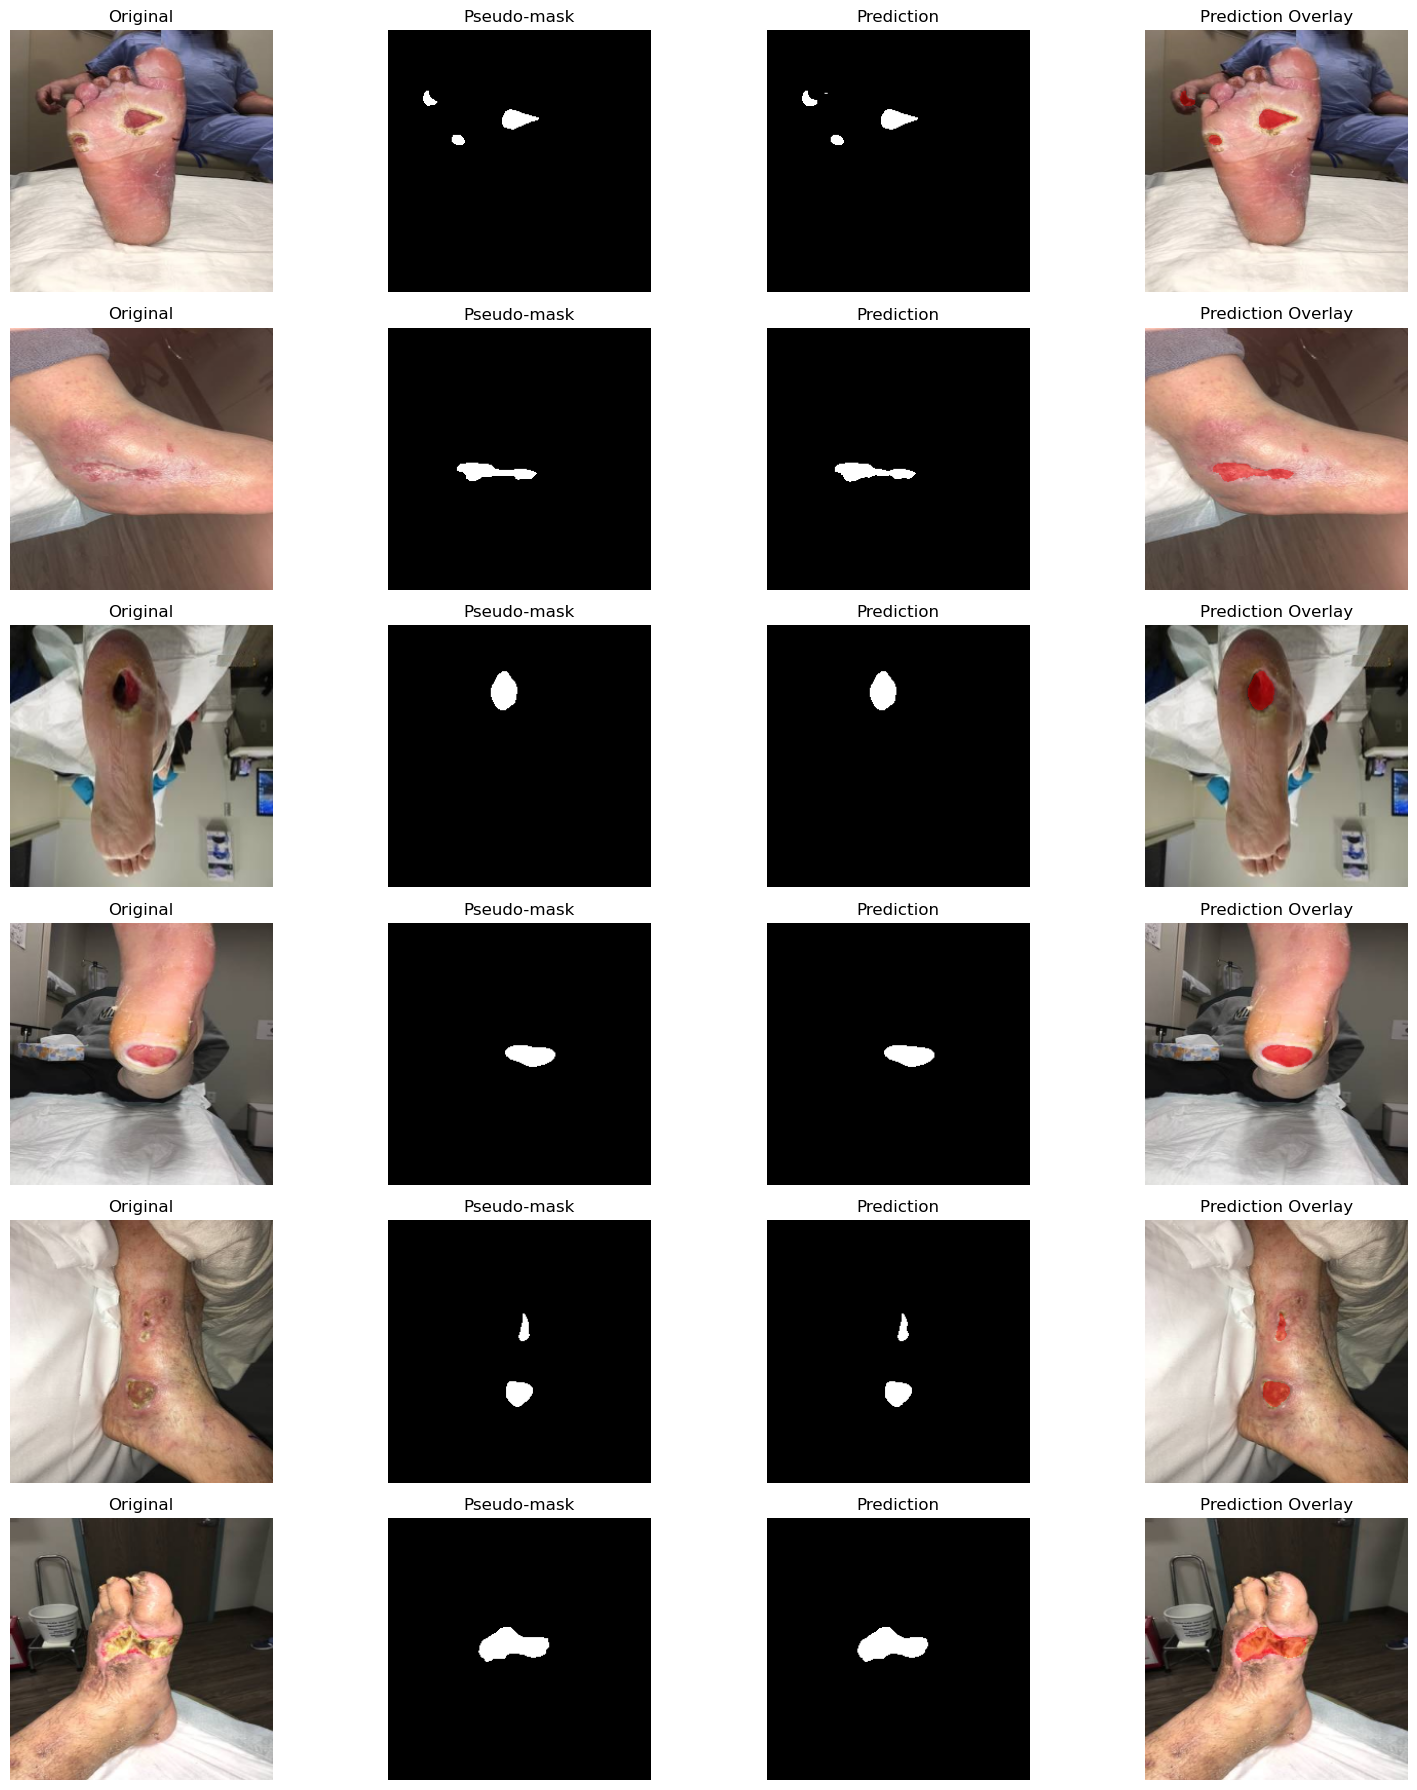

In [19]:
import random

# Take 6 random samples from validation set
sample_pairs = random.sample(val_pairs, 6)

plt.figure(figsize=(16, 18))

for i, (image_path, mask_path) in enumerate(sample_pairs):

    # Load image
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_resized = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Load pseudo-mask
    true_mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    true_mask = cv2.resize(
        true_mask,
        (IMG_SIZE, IMG_SIZE),
        interpolation=cv2.INTER_NEAREST
    )

    true_mask = (true_mask > 127).astype(np.float32)

    # Model prediction
    input_image = image_resized.astype(np.float32) / 255.0
    prediction = final_model.predict(
        np.expand_dims(input_image, axis=0),
        verbose=0
    )[0, :, :, 0]

    pred_mask = (prediction >= 0.5).astype(np.float32)

    # Overlay prediction
    overlay = image_resized.copy()
    overlay[pred_mask == 1] = (
        0.6 * overlay[pred_mask == 1] +
        0.4 * np.array([255, 0, 0])
    ).astype(np.uint8)

    # Plot
    plt.subplot(6, 4, i * 4 + 1)
    plt.imshow(image_resized)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(6, 4, i * 4 + 2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Pseudo-mask")
    plt.axis("off")

    plt.subplot(6, 4, i * 4 + 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

    plt.subplot(6, 4, i * 4 + 4)
    plt.imshow(overlay)
    plt.title("Prediction Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()